In [36]:
import xgboost as xgb
import model_XGBoost as xgb_model

from sklearn.metrics import accuracy_score
from sklearn.preprocessing import OneHotEncoder

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from dateutil.relativedelta import relativedelta
import datetime as dt
import holidays
holidays_de= holidays.Germany()

from sklearn.metrics import mean_squared_error
from sklearn.model_selection import RandomizedSearchCV, GridSearchCV
import scipy.stats as stats

plt.rcParams['figure.figsize'] = [12, 6]
plt.rcParams['figure.dpi'] = 100

In [37]:
df_all = pd.read_csv('../../data_cleaned/merged/02_4_clean_data.csv')
df_all.head()

,date,year,month,day,dayofyear,hour,week,dayofweek,price,period_start_utc,...,interpolated,dayofyear_sin1,dayofyear_cos1,hour_sin1,hour_cos1,dayofweek_sin1,dayofweek_cos1,is_holiday,day_type,price_gas
0,2019-01-01,2019,1,1,1,0,1,1,10.07,2019-01-01 00:00:00+00:00,...,0,0.0,1.0,0.000000,1.000000,0.781831,0.62349,1,holiday,22.28
1,2019-01-01,2019,1,1,1,1,1,1,-4.08,2019-01-01 01:00:00+00:00,...,0,0.0,1.0,0.258819,0.965926,0.781831,0.62349,1,holiday,22.28
2,2019-01-01,2019,1,1,1,2,1,1,-9.91,2019-01-01 02:00:00+00:00,...,0,0.0,1.0,0.500000,0.866025,0.781831,0.62349,1,holiday,22.28
3,2019-01-01,2019,1,1,1,3,1,1,-7.41,2019-01-01 03:00:00+00:00,...,0,0.0,1.0,0.707107,0.707107,0.781831,0.62349,1,holiday,22.28
4,2019-01-01,2019,1,1,1,4,1,1,-12.55,2019-01-01 04:00:00+00:00,...,0,0.0,1.0,0.866025,0.500000,0.781831,0.62349,1,holiday,22.28


In [38]:
df_years = df_all.query('2019 <= year').copy()
df_years.head()

,date,year,month,day,dayofyear,hour,week,dayofweek,price,period_start_utc,...,interpolated,dayofyear_sin1,dayofyear_cos1,hour_sin1,hour_cos1,dayofweek_sin1,dayofweek_cos1,is_holiday,day_type,price_gas
0,2019-01-01,2019,1,1,1,0,1,1,10.07,2019-01-01 00:00:00+00:00,...,0,0.0,1.0,0.000000,1.000000,0.781831,0.62349,1,holiday,22.28
1,2019-01-01,2019,1,1,1,1,1,1,-4.08,2019-01-01 01:00:00+00:00,...,0,0.0,1.0,0.258819,0.965926,0.781831,0.62349,1,holiday,22.28
2,2019-01-01,2019,1,1,1,2,1,1,-9.91,2019-01-01 02:00:00+00:00,...,0,0.0,1.0,0.500000,0.866025,0.781831,0.62349,1,holiday,22.28
3,2019-01-01,2019,1,1,1,3,1,1,-7.41,2019-01-01 03:00:00+00:00,...,0,0.0,1.0,0.707107,0.707107,0.781831,0.62349,1,holiday,22.28
4,2019-01-01,2019,1,1,1,4,1,1,-12.55,2019-01-01 04:00:00+00:00,...,0,0.0,1.0,0.866025,0.500000,0.781831,0.62349,1,holiday,22.28


In [39]:
df_years = pd.get_dummies(df_years, columns=['year'], drop_first=True)
df_years.head()

,date,month,day,dayofyear,hour,week,dayofweek,price,period_start_utc,period_end_utc,...,dayofweek_cos1,is_holiday,day_type,price_gas,year_2020,year_2021,year_2022,year_2023,year_2024,year_2025
0,2019-01-01,1,1,1,0,1,1,10.07,2019-01-01 00:00:00+00:00,2019-01-01 01:00:00+00:00,...,0.62349,1,holiday,22.28,False,False,False,False,False,False
1,2019-01-01,1,1,1,1,1,1,-4.08,2019-01-01 01:00:00+00:00,2019-01-01 02:00:00+00:00,...,0.62349,1,holiday,22.28,False,False,False,False,False,False
2,2019-01-01,1,1,1,2,1,1,-9.91,2019-01-01 02:00:00+00:00,2019-01-01 03:00:00+00:00,...,0.62349,1,holiday,22.28,False,False,False,False,False,False
3,2019-01-01,1,1,1,3,1,1,-7.41,2019-01-01 03:00:00+00:00,2019-01-01 04:00:00+00:00,...,0.62349,1,holiday,22.28,False,False,False,False,False,False
4,2019-01-01,1,1,1,4,1,1,-12.55,2019-01-01 04:00:00+00:00,2019-01-01 05:00:00+00:00,...,0.62349,1,holiday,22.28,False,False,False,False,False,False


In [40]:
df_years.drop(columns=['period_end_utc'], inplace=True)

In [41]:
df_years["period_start_utc"] = pd.to_datetime(df_years["period_start_utc"], errors="coerce")
df_years["period_start_utc"] = df_years["period_start_utc"].apply(lambda x: x.replace(tzinfo=None))
df_years["date"] = pd.to_datetime(df_years["date"], errors="coerce")

In [42]:
df_years.info()

<class 'pandas.core.frame.DataFrame'>
Index: 61367 entries, 0 to 61366
Data columns (total 39 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   date              61367 non-null  datetime64[ns]
 1   month             61367 non-null  int64         
 2   day               61367 non-null  int64         
 3   dayofyear         61367 non-null  int64         
 4   hour              61367 non-null  int64         
 5   week              61367 non-null  int64         
 6   dayofweek         61367 non-null  int64         
 7   price             61367 non-null  float64       
 8   period_start_utc  61367 non-null  datetime64[ns]
 9   c_by_hour         61367 non-null  int64         
 10  load_forecast_da  61367 non-null  float64       
 11  load_actual       61367 non-null  float64       
 12  off_wind_da       61367 non-null  float64       
 13  off_wind_act      61367 non-null  float64       
 14  on_wind_da        61367 non

In [43]:
df_years.head()

,date,month,day,dayofyear,hour,week,dayofweek,price,period_start_utc,c_by_hour,...,dayofweek_cos1,is_holiday,day_type,price_gas,year_2020,year_2021,year_2022,year_2023,year_2024,year_2025
0,2019-01-01,1,1,1,0,1,1,10.07,2019-01-01 00:00:00,4,...,0.62349,1,holiday,22.28,False,False,False,False,False,False
1,2019-01-01,1,1,1,1,1,1,-4.08,2019-01-01 01:00:00,4,...,0.62349,1,holiday,22.28,False,False,False,False,False,False
2,2019-01-01,1,1,1,2,1,1,-9.91,2019-01-01 02:00:00,4,...,0.62349,1,holiday,22.28,False,False,False,False,False,False
3,2019-01-01,1,1,1,3,1,1,-7.41,2019-01-01 03:00:00,4,...,0.62349,1,holiday,22.28,False,False,False,False,False,False
4,2019-01-01,1,1,1,4,1,1,-12.55,2019-01-01 04:00:00,4,...,0.62349,1,holiday,22.28,False,False,False,False,False,False


In [44]:
df_years.set_index('period_start_utc', inplace=True)

In [45]:
df_years.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 61367 entries, 2019-01-01 00:00:00 to 2025-12-31 22:00:00
Data columns (total 38 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   date              61367 non-null  datetime64[ns]
 1   month             61367 non-null  int64         
 2   day               61367 non-null  int64         
 3   dayofyear         61367 non-null  int64         
 4   hour              61367 non-null  int64         
 5   week              61367 non-null  int64         
 6   dayofweek         61367 non-null  int64         
 7   price             61367 non-null  float64       
 8   c_by_hour         61367 non-null  int64         
 9   load_forecast_da  61367 non-null  float64       
 10  load_actual       61367 non-null  float64       
 11  off_wind_da       61367 non-null  float64       
 12  off_wind_act      61367 non-null  float64       
 13  on_wind_da        61367 non-null  float64

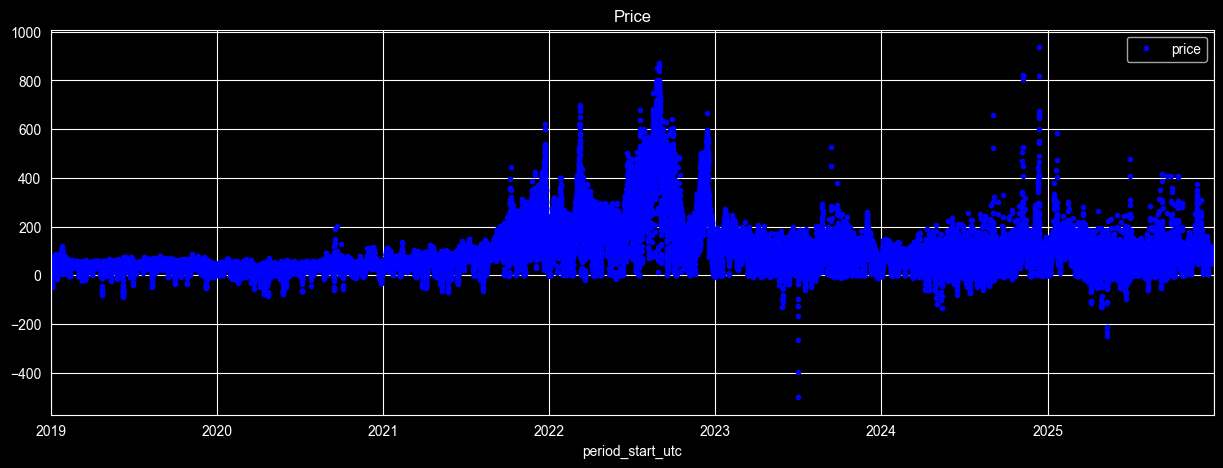

In [46]:
df_years.plot( y='price', style='.', figsize=(15, 5), color='blue', title='Price')
plt.show()

# Train / Test Split

In [47]:
start_date = pd.to_datetime('2019-01-01 00:00:00')
split_date = pd.to_datetime('2025-01-01 00:00:00')
end_date = pd.to_datetime('2026-01-01 00:00:00')

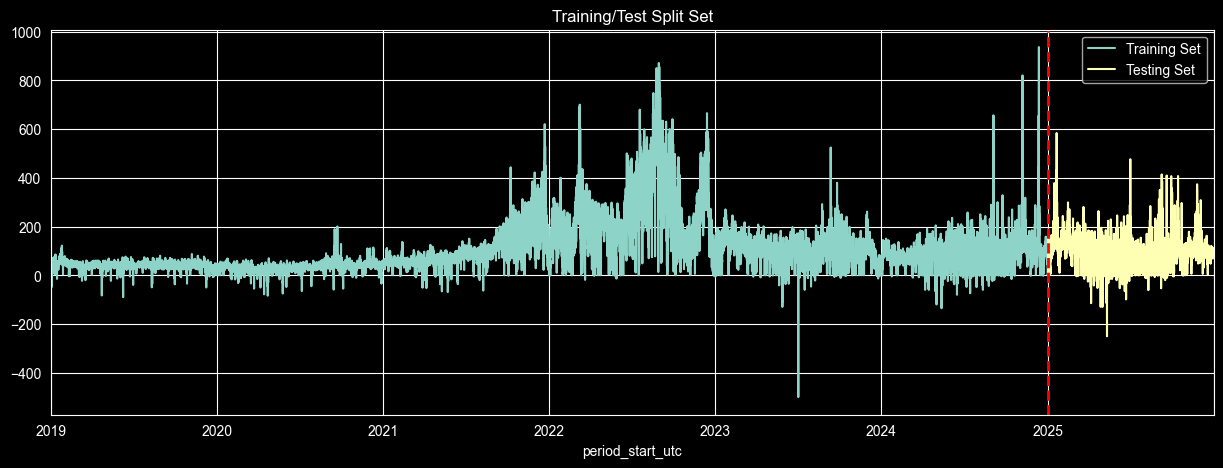

In [48]:
train = df_years.query('@start_date <= date < @split_date')
test = df_years.query('@split_date <= date < @end_date')

#train = df_years.query('date < 2021')
#test = df_years.query('2021 <= date < "2021-07"')

fig, ax = plt.subplots(figsize=(15, 5))
train.plot(y='price', ax=ax, label='Training Set', title='Training/Test Split Set')
test.plot(y='price', ax=ax, label = 'Testing Set')
ax.axvline(split_date, color='red', linestyle='dashed', linewidth=2)
plt.legend()
plt.show()

# Feature Creation

In [49]:
df_years.index

DatetimeIndex(['2019-01-01 00:00:00', '2019-01-01 01:00:00',
               '2019-01-01 02:00:00', '2019-01-01 03:00:00',
               '2019-01-01 04:00:00', '2019-01-01 05:00:00',
               '2019-01-01 06:00:00', '2019-01-01 07:00:00',
               '2019-01-01 08:00:00', '2019-01-01 09:00:00',
               ...
               '2025-12-31 13:00:00', '2025-12-31 14:00:00',
               '2025-12-31 15:00:00', '2025-12-31 16:00:00',
               '2025-12-31 17:00:00', '2025-12-31 18:00:00',
               '2025-12-31 19:00:00', '2025-12-31 20:00:00',
               '2025-12-31 21:00:00', '2025-12-31 22:00:00'],
              dtype='datetime64[ns]', name='period_start_utc', length=61367, freq=None)

In [50]:
def create_features(df):
    """
    create time series features based on time series index
    :param df:
    :return:
    """
    df = df.copy()

    df['hour'] = df.index.hour
    df['dayofweek'] = df.index.dayofweek
    df['weekday'] = df.index.weekday
    df['quarter'] = df.index.quarter
    df['month'] = df.index.month
    df['year'] = df.index.year
    df['dayofyear'] = df.index.dayofyear
    return df

Text(0.5, 1.0, 'Price by Hour')

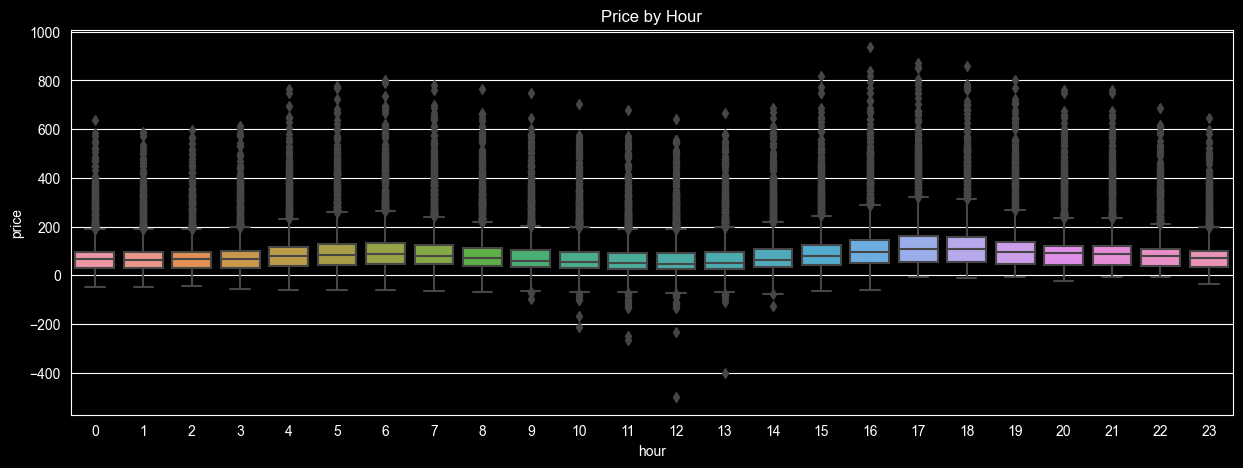

In [51]:
fig, ax = plt.subplots(figsize=(15, 5))
sns.boxplot(data = df_years, x = 'hour', y= 'price')
ax.set_title('Price by Hour')

Text(0.5, 1.0, 'Price by Month')

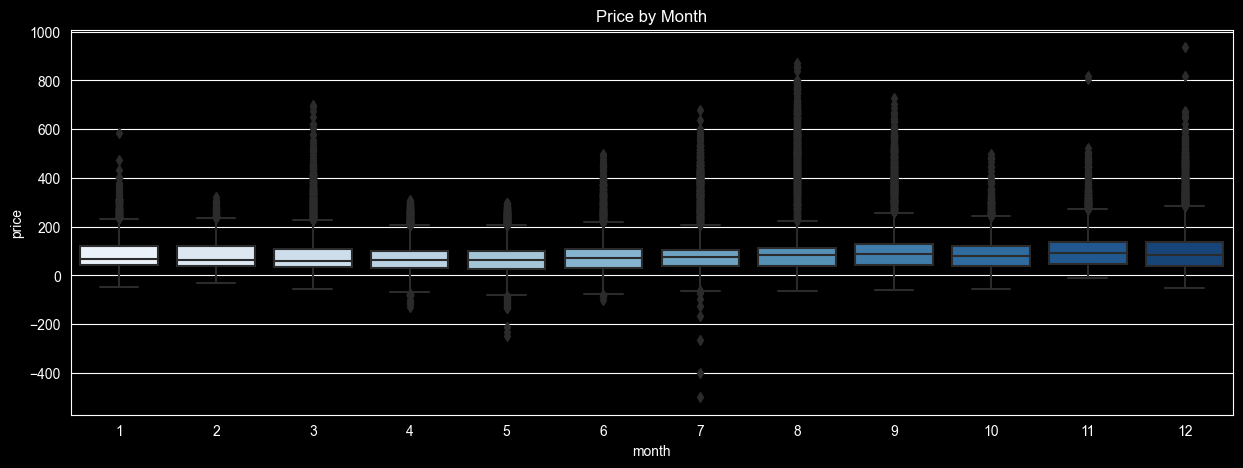

In [52]:
fig, ax = plt.subplots(figsize=(15, 5))
sns.boxplot(data = df_years, x = 'month', y= 'price', palette='Blues')
ax.set_title('Price by Month')

# Create Model

In [53]:
df_years.columns

Index(['date', 'month', 'day', 'dayofyear', 'hour', 'week', 'dayofweek',
       'price', 'c_by_hour', 'load_forecast_da', 'load_actual', 'off_wind_da',
       'off_wind_act', 'on_wind_da', 'on_wind_act', 'solar_da', 'solar_act',
       'gen_forecast_da', 'gen_actual', 'res_sum_da', 'res_sum_act', 'imputed',
       'interpolated', 'dayofyear_sin1', 'dayofyear_cos1', 'hour_sin1',
       'hour_cos1', 'dayofweek_sin1', 'dayofweek_cos1', 'is_holiday',
       'day_type', 'price_gas', 'year_2020', 'year_2021', 'year_2022',
       'year_2023', 'year_2024', 'year_2025'],
      dtype='object')

In [54]:
#FEATURES = ['year', 'month', 'day', 'dayofyear', 'hour', 'week', 'dayofweek', 'load_forecast_da', 'res_sum_da', 'dayofyear_sin1',
#       'dayofyear_cos1', 'hour_sin1', 'hour_cos1', 'dayofweek_sin1',
#       'dayofweek_cos1', 'is_holiday', 'price_gas']
FEATURES = ['load_forecast_da', 'res_sum_da', 'gen_forecast_da', 'dayofyear_sin1',
       'dayofyear_cos1', 'hour_sin1', 'hour_cos1', 'dayofweek_sin1',
       'dayofweek_cos1', 'is_holiday', 'price_gas', 'year_2020', 'year_2021', 'year_2022',
       'year_2023', 'year_2024', 'year_2025']
#FEATURES = ['year', 'price_gas', 'res_sum_da', 'load_forecast_da']
TARGET = 'price'

In [55]:
reg = xgb_model.create_and_train_XGBoost(train, test, FEATURES, TARGET)

[0]	validation_0-rmse:136.76524	validation_1-rmse:102.69486
[50]	validation_0-rmse:89.64299	validation_1-rmse:71.16791


C:\Users\bened\Documents\neuefische\capstone-project\ai-for-energy\.venv\Lib\site-packages\xgboost\callback.py:385: UserWarning: [16:02:07] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "enable_categorial" } are not used.

  self.starting_round = model.num_boosted_rounds()


[100]	validation_0-rmse:60.36940	validation_1-rmse:52.06811
[150]	validation_0-rmse:43.36320	validation_1-rmse:40.76656
[200]	validation_0-rmse:33.25884	validation_1-rmse:35.31631
[250]	validation_0-rmse:27.45092	validation_1-rmse:32.40542
[300]	validation_0-rmse:23.99282	validation_1-rmse:30.64934
[350]	validation_0-rmse:21.94558	validation_1-rmse:29.42885
[400]	validation_0-rmse:20.63398	validation_1-rmse:28.76159
[450]	validation_0-rmse:19.67269	validation_1-rmse:28.41701
[500]	validation_0-rmse:18.97613	validation_1-rmse:28.17112
[550]	validation_0-rmse:18.41845	validation_1-rmse:28.07258
[600]	validation_0-rmse:17.94998	validation_1-rmse:28.02669
[650]	validation_0-rmse:17.55970	validation_1-rmse:28.00655
[700]	validation_0-rmse:17.23266	validation_1-rmse:27.97567
[750]	validation_0-rmse:16.93416	validation_1-rmse:27.96524
[800]	validation_0-rmse:16.64957	validation_1-rmse:27.96258
[850]	validation_0-rmse:16.38699	validation_1-rmse:27.95142
[900]	validation_0-rmse:16.15045	validat

In [56]:
#reg.score()

# Feature Importance

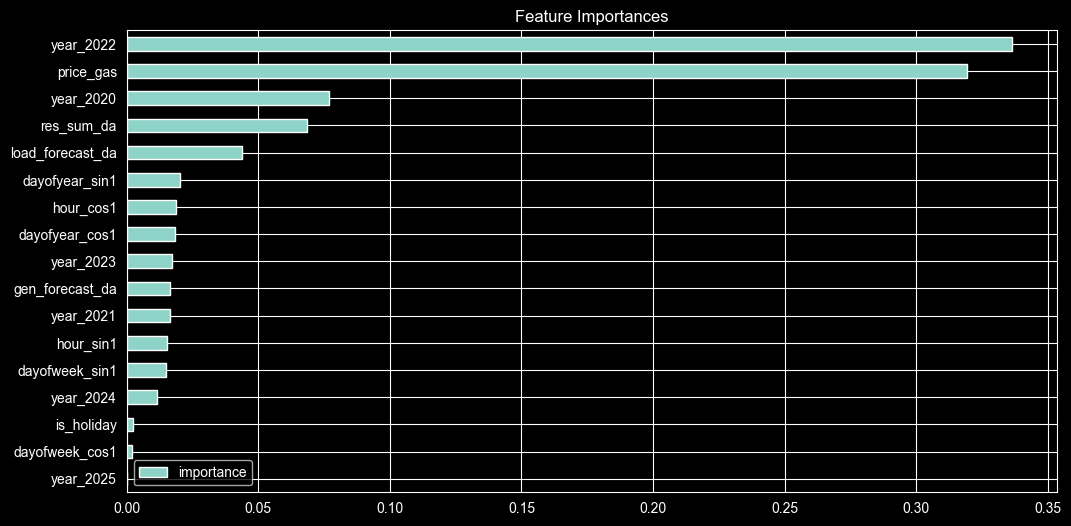

In [57]:
xgb_model.display_feature_importance(reg)

# Forecast on Test

In [58]:
test['prediction'] = reg.predict(test[FEATURES])

C:\Users\bened\AppData\Local\Temp\ipykernel_32588\677415749.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  test['prediction'] = reg.predict(test[FEATURES])


In [59]:
df_years = df_years.merge(test[['prediction']],  how = 'left', left_index=True, right_index=True) # merge on index columns

In [60]:
df_years

,date,month,day,dayofyear,hour,week,dayofweek,price,c_by_hour,load_forecast_da,...,is_holiday,day_type,price_gas,year_2020,year_2021,year_2022,year_2023,year_2024,year_2025,prediction
period_start_utc,,,,,,,,,,,,,,,,,,,,,
2019-01-01 00:00:00,2019-01-01,1,1,1,0,1,1,10.0700,4,41692.5650,...,1,holiday,22.280,False,False,False,False,False,False,NaN
2019-01-01 01:00:00,2019-01-01,1,1,1,1,1,1,-4.0800,4,40587.2325,...,1,holiday,22.280,False,False,False,False,False,False,NaN
2019-01-01 02:00:00,2019-01-01,1,1,1,2,1,1,-9.9100,4,40308.2500,...,1,holiday,22.280,False,False,False,False,False,False,NaN
2019-01-01 03:00:00,2019-01-01,1,1,1,3,1,1,-7.4100,4,40659.5750,...,1,holiday,22.280,False,False,False,False,False,False,NaN
2019-01-01 04:00:00,2019-01-01,1,1,1,4,1,1,-12.5500,4,40947.7300,...,1,holiday,22.280,False,False,False,False,False,False,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2025-12-31 18:00:00,2025-12-31,12,31,365,18,1,2,95.9900,4,61429.2525,...,0,weekday,27.755,False,False,False,False,False,True,69.088715
2025-12-31 19:00:00,2025-12-31,12,31,365,19,1,2,86.8025,4,58695.5025,...,0,weekday,27.755,False,False,False,False,False,True,63.885216
2025-12-31 20:00:00,2025-12-31,12,31,365,20,1,2,79.7975,4,55991.9725,...,0,weekday,27.755,False,False,False,False,False,True,58.992527


In [61]:
df_years.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 61367 entries, 2019-01-01 00:00:00 to 2025-12-31 22:00:00
Data columns (total 39 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   date              61367 non-null  datetime64[ns]
 1   month             61367 non-null  int64         
 2   day               61367 non-null  int64         
 3   dayofyear         61367 non-null  int64         
 4   hour              61367 non-null  int64         
 5   week              61367 non-null  int64         
 6   dayofweek         61367 non-null  int64         
 7   price             61367 non-null  float64       
 8   c_by_hour         61367 non-null  int64         
 9   load_forecast_da  61367 non-null  float64       
 10  load_actual       61367 non-null  float64       
 11  off_wind_da       61367 non-null  float64       
 12  off_wind_act      61367 non-null  float64       
 13  on_wind_da        61367 non-null  float64

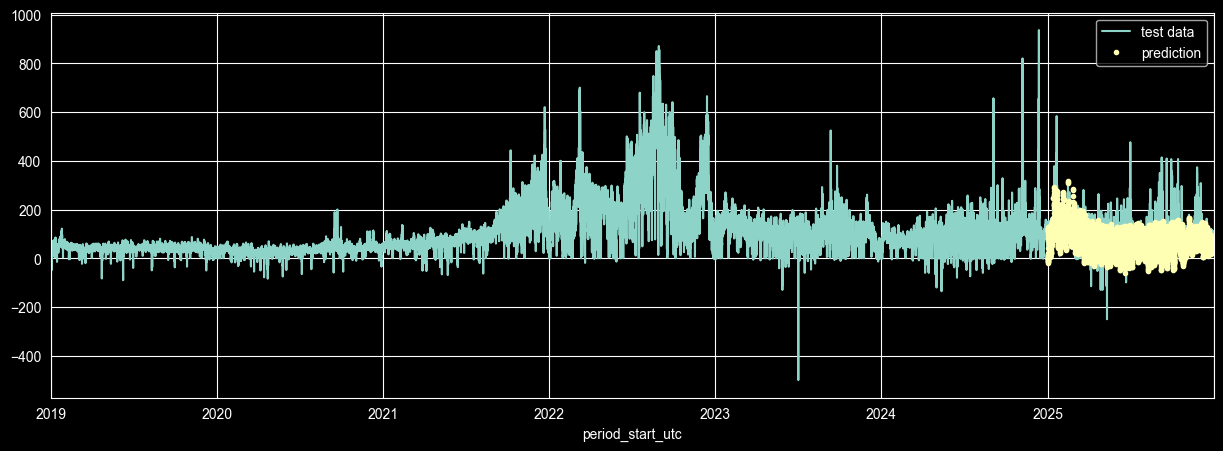

Text(0.5, 1.0, 'Test Data and Predictions')

In [62]:
ax = df_years[['price']].plot(figsize=(15, 5))
df_years['prediction'].plot(ax=ax, style = '.')
plt.legend(['test data', 'prediction'])
plt.show()
ax.set_title('Test Data and Predictions')

# smaller test frames

In [63]:
add_three_months = relativedelta(months=3)
add_one_week = relativedelta(days=7)

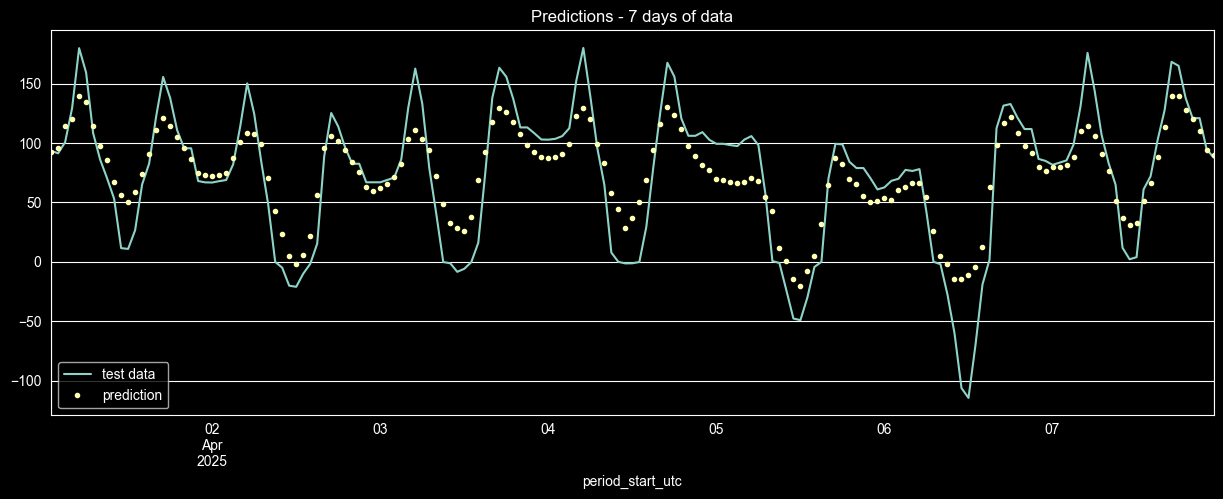

In [64]:
first_day_four_months_in = split_date + add_three_months
first_day_four_months_in.to_datetime64()
last_day_four_months_in = first_day_four_months_in + add_one_week
last_day_four_months_in.to_datetime64()

ax = df_years.loc[(first_day_four_months_in < df_years.index) & (df_years.index < last_day_four_months_in)]['price'].plot(figsize=(15, 5), title='Predictions - 7 days of data')
df_years.loc[(first_day_four_months_in < df_years.index) & (df_years.index < last_day_four_months_in)]['prediction'].plot(ax=ax, style='.')
plt.legend(['test data', 'prediction'])
plt.show()

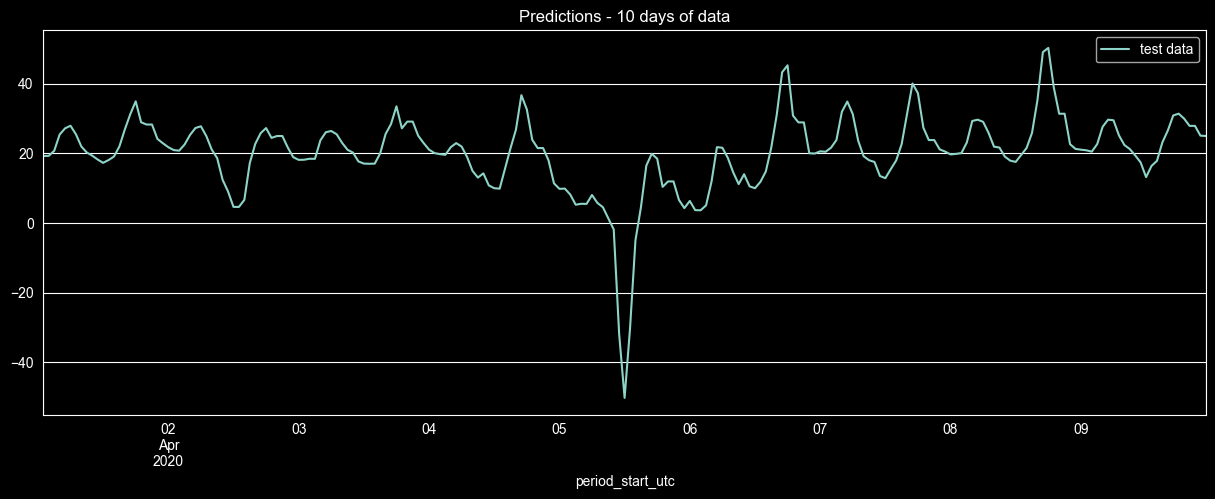

In [65]:
ax = df_years.loc[("2020-04-01" < df_years.index) & (df_years.index < "2020-04-10")]['price'].plot(figsize=(15, 5), title='Predictions - 10 days of data')
plt.legend(['test data'])
plt.show()

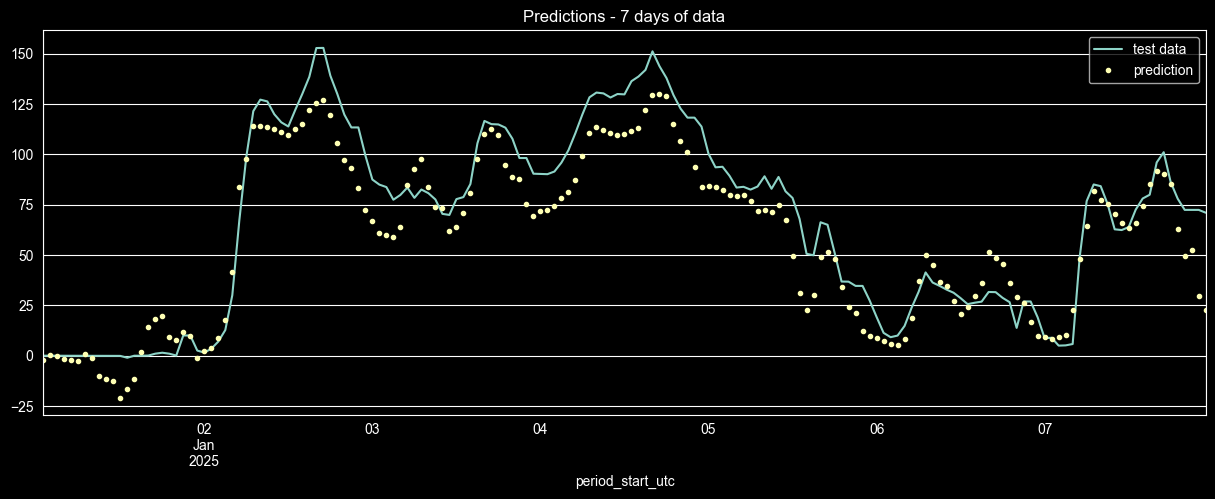

In [66]:
split_date_one_week_in = split_date + add_one_week

ax = df_years.loc[(split_date < df_years.index) & (df_years.index < split_date_one_week_in)]['price'].plot(figsize=(15, 5), title='Predictions - 7 days of data')
df_years.loc[(split_date < df_years.index) & (df_years.index < split_date_one_week_in)]['prediction'].plot(ax=ax, style='.')
plt.legend(['test data', 'prediction'])
plt.show()

# Using Grid/Randomizer Search

In [67]:
# Define the hyperparameter distributions
param_grid = {
    'max_depth': [3, 5, 7],
    'learning_rate': [0.1, 0.01, 0.001],
    'subsample': [0.5, 0.7, 1]
}

In [68]:
xgb_model.paramater_search_XGBoost(train, FEATURES, TARGET, 'grid', param_grid)

C:\Users\bened\Documents\neuefische\capstone-project\ai-for-energy\.venv\Lib\site-packages\sklearn\model_selection\_validation.py:778: UserWarning: Scoring failed. The score on this train-test partition for these parameters will be set to nan. Details: 
Traceback (most recent call last):
  File "C:\Users\bened\Documents\neuefische\capstone-project\ai-for-energy\.venv\Lib\site-packages\sklearn\model_selection\_validation.py", line 767, in _score
    scores = scorer(estimator, X_test, y_test)
             ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "C:\Users\bened\Documents\neuefische\capstone-project\ai-for-energy\.venv\Lib\site-packages\sklearn\metrics\_scorer.py", line 234, in __call__
    return self._score(
           ^^^^^^^^^^^^
  File "C:\Users\bened\Documents\neuefische\capstone-project\ai-for-energy\.venv\Lib\site-packages\sklearn\metrics\_scorer.py", line 282, in _score
    return self._sign * self._score_func(y_true, y_pred, **self._kwargs)
                        ^^^^^^^^^^^^^^

Best set of hyperparameters:  {'learning_rate': 0.1, 'max_depth': 3, 'subsample': 0.5}
Best score:  nan


C:\Users\bened\Documents\neuefische\capstone-project\ai-for-energy\.venv\Lib\site-packages\sklearn\model_selection\_validation.py:778: UserWarning: Scoring failed. The score on this train-test partition for these parameters will be set to nan. Details: 
Traceback (most recent call last):
  File "C:\Users\bened\Documents\neuefische\capstone-project\ai-for-energy\.venv\Lib\site-packages\sklearn\model_selection\_validation.py", line 767, in _score
    scores = scorer(estimator, X_test, y_test)
             ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "C:\Users\bened\Documents\neuefische\capstone-project\ai-for-energy\.venv\Lib\site-packages\sklearn\metrics\_scorer.py", line 234, in __call__
    return self._score(
           ^^^^^^^^^^^^
  File "C:\Users\bened\Documents\neuefische\capstone-project\ai-for-energy\.venv\Lib\site-packages\sklearn\metrics\_scorer.py", line 282, in _score
    return self._sign * self._score_func(y_true, y_pred, **self._kwargs)
                        ^^^^^^^^^^^^^^

In [69]:
# Define the hyperparameter distributions
param_dist = {
    'base_score':stats.uniform(0.4, 0.6),
    'max_depth': stats.randint(3, 10),
    'learning_rate': stats.uniform(0.001, 0.1),
    'subsample': stats.uniform(0.5, 0.9),
    'n_estimators':stats.randint(100, 2000),
    'colsample_bytree':stats.uniform(0.5, 0.8)
}

In [70]:
xgb_model.paramater_search_XGBoost(train, FEATURES, TARGET, 'random', param_dist)

C:\Users\bened\Documents\neuefische\capstone-project\ai-for-energy\.venv\Lib\site-packages\sklearn\model_selection\_validation.py:378: FitFailedWarning: 
30 fits failed out of a total of 50.
The score on these train-test partitions for these parameters will be set to nan.
If these failures are not expected, you can try to debug them by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
5 fits failed with the following error:
Traceback (most recent call last):
  File "C:\Users\bened\Documents\neuefische\capstone-project\ai-for-energy\.venv\Lib\site-packages\sklearn\model_selection\_validation.py", line 686, in _fit_and_score
    estimator.fit(X_train, y_train, **fit_params)
  File "C:\Users\bened\Documents\neuefische\capstone-project\ai-for-energy\.venv\Lib\site-packages\xgboost\core.py", line 751, in inner_f
    return func(**kwargs)
           ^^^^^^^^^^^^^^
  File "C:\Users\bened\Do

Best set of hyperparameters:  {'base_score': 0.46061992036493105, 'colsample_bytree': 0.9236091764563839, 'learning_rate': 0.035246895916213376, 'max_depth': 5, 'n_estimators': 401, 'subsample': 0.6086028449008904}
Best score:  -33.15799554147112
